Step 1 :

In [1]:
!pip install -q albumentations scikit-learn matplotlib torchvision torch

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import urllib.request
import tarfile
import kagglehub


# Download latest version
path = kagglehub.dataset_download("thtuan/mvtecad-mvtec-anomaly-detection")

print("Path to dataset files:", path)

print("Downloading MVTec AD dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("thtuan/mvtecad-mvtec-anomaly-detection")

print("Path to dataset files:", dataset_path)
# 2. Search for the actual location of the 'bottle' directory
bottle_path = None
for root, dirs, files in os.walk(dataset_path):
    if "bottle" in dirs:
        bottle_path = os.path.join(root, "bottle")
        break

if bottle_path and os.path.exists(os.path.join(bottle_path, "train", "good")):
    print("✅ Found bottle directory successfully at:", bottle_path)
else:
    print("❌ Could not locate bottle directory automatically. Top directory contains:", os.listdir(dataset_path))


if os.path.exists(bottle_path):
    print("Bottle dataset located successfully at:", bottle_path)
else:
    print("Directory contents:", os.listdir(dataset_path))


100%|██████████| 4.91G/4.91G [00:49<00:00, 107MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thtuan/mvtecad-mvtec-anomaly-detection/versions/2
Using Colab cache for faster access to the 'mvtecad-mvtec-anomaly-detection' dataset.
Path to dataset files: /kaggle/input/mvtecad-mvtec-anomaly-detection
✅ Found bottle directory successfully at: /kaggle/input/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle
Bottle dataset located successfully at: /kaggle/input/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle


Step 2

Step 2
PyTorch Dataset & Preprocessing Pipeline.

In [2]:
class MVTecSimpleDataset(Dataset):
    def __init__(self, root_dir, split='train', img_size=256):
        self.img_size = img_size
        self.split = split
        self.image_paths = []
        self.labels = [] # 0 = Normal, 1 = Defective

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Z-score Standardization
        ])

        if split == 'train':
            train_good_dir = os.path.join(root_dir, 'train', 'good')
            for img_name in sorted(os.listdir(train_good_dir)):
                if not img_name.startswith('.'):
                    self.image_paths.append(os.path.join(train_good_dir, img_name))
                    self.labels.append(0) # All train images are normal !!!
        else:
            test_dir = os.path.join(root_dir, 'test')
            for sub_folder in os.listdir(test_dir):
                sub_path = os.path.join(test_dir, sub_folder)
                label = 0 if sub_folder == 'good' else 1
                for img_name in os.listdir(sub_path):
                    self.image_paths.append(os.path.join(sub_path, img_name))
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        tensor_img = self.transform(image)
        return tensor_img, self.labels[idx]


train_dataset = MVTecSimpleDataset(bottle_path, split='train', img_size=256)
test_dataset = MVTecSimpleDataset(bottle_path, split='test', img_size=256)
# Instantiate DataLoaders

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Train (Normal) samples: {len(train_dataset)}")
print(f"Test samples (Normal + Defective): {len(test_dataset)}")

Train (Normal) samples: 209
Test samples (Normal + Defective): 83


step 3 : Encoder


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class BottleAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(BottleAutoencoder, self).__init__()

        # Encoder: 256x256x3 -> ... -> 32x32x128 -> Flattened -> 128
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # [32, 128, 128]
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # [64, 64, 64]
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),# [128, 32, 32]
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )

        #  Bottleneck Layers: Force severe compression
        self.flatten = nn.Flatten()
        self.fc_encode = nn.Linear(32 * 32 * 128, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 32 * 32 * 128)
        self.unflatten = nn.Unflatten(1, (128, 32, 32))

        # Decoder: 32x32x128 -> ... -> 256x256x3
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # [64, 64, 64]
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # [32, 128, 128]
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),   # [3, 256, 256]
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.fc_encode(x)
        x = self.fc_decode(x)
        x = self.unflatten(x)
        decoded = self.decoder(x)
        return decoded

# 2. Setup Device, Initialize Model, Criterion, Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BottleAutoencoder(latent_dim=128).to(device) # Try 128 or 64 for stronger compression ?
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Lower LR for stability !!!

# 3. Training Loop
print("Training Bottleneck Autoencoder (healing model)...")
model.train()
total_epochs = 20
for epoch in range(total_epochs):
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{total_epochs}], Loss: {epoch_loss:.6f}")

print("Training complete.")

Training Bottleneck Autoencoder (healing model)...
Epoch [1/20], Loss: 2.888092
Epoch [2/20], Loss: 2.345478
Epoch [3/20], Loss: 1.875577
Epoch [4/20], Loss: 1.620295
Epoch [5/20], Loss: 1.454952
Epoch [6/20], Loss: 1.334442
Epoch [7/20], Loss: 1.245230
Epoch [8/20], Loss: 1.177491
Epoch [9/20], Loss: 1.119622
Epoch [10/20], Loss: 1.071288
Epoch [11/20], Loss: 1.034372
Epoch [12/20], Loss: 1.004856
Epoch [13/20], Loss: 0.980879
Epoch [14/20], Loss: 0.961023
Epoch [15/20], Loss: 0.944494
Epoch [16/20], Loss: 0.930606
Epoch [17/20], Loss: 0.918667
Epoch [18/20], Loss: 0.908368
Epoch [19/20], Loss: 0.899341
Epoch [20/20], Loss: 0.891415
Training complete.


Step 4
Dummy Classifier vs Autoencoder Baseline

In [4]:
model.eval()
true_labels = []
autoencoder_scores = []

with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        recon = model(img)

        # Calculate pixel-wise Mean Squared Error as Anomaly Score
        mse_score = torch.mean((img - recon) ** 2).item()

        autoencoder_scores.append(mse_score)
        true_labels.append(label.item())

# --- 1. DUMMY CLASSIFIER (Always Predicts Defective = 1) ---
dummy_predictions = [1] * len(true_labels)

dummy_acc = accuracy_score(true_labels, dummy_predictions)
dummy_f1 = f1_score(true_labels, dummy_predictions)

# --- 2. SIMPLE AUTOENCODER BASELINE METRICS ---
ae_auroc = roc_auc_score(true_labels, autoencoder_scores)

print("=" * 60)
print("SUPERVISOR DEMONSTRATION RESULTS")
print("=" * 60)
print(f"1. DUMMY CLASSIFIER (Always Predicts Defective):")
print(f"   - Dummy Accuracy: {dummy_acc * 100:.2f}%  <-- (Artificially High!)")
print(f"   - Dummy F1-Score: {dummy_f1:.4f}")
print("\n2. SIMPLE CONVOLUTIONAL AUTOENCODER BASELINE:")
print(f"   - Baseline Image-AUROC Score: {ae_auroc:.4f}")
print("=" * 60)

SUPERVISOR DEMONSTRATION RESULTS
1. DUMMY CLASSIFIER (Always Predicts Defective):
   - Dummy Accuracy: 75.90%  <-- (Artificially High!)
   - Dummy F1-Score: 0.8630

2. SIMPLE CONVOLUTIONAL AUTOENCODER BASELINE:
   - Baseline Image-AUROC Score: 0.6603


Step 5 : Visualization

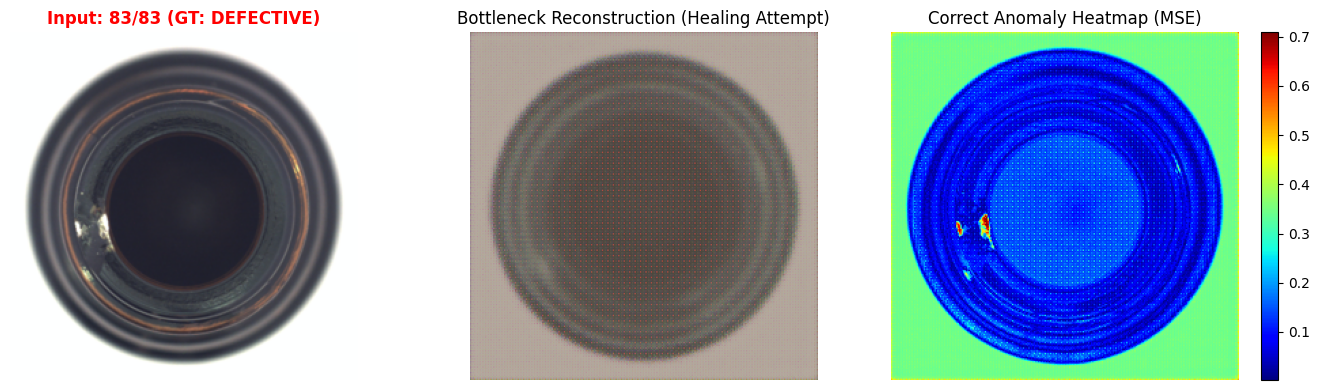

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import time
from IPython import display

model.eval()

# Loop through all available images in the test set
for idx in range(len(test_dataset)):
    sample_img, sample_label = test_dataset[idx] # Get the normalized tensor
    sample_tensor = sample_img.unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor = model(sample_tensor)

    # 1. Denormalize for Visualisation
    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)

    # Move tensor to numpy, reorder axes to [H, W, C]
    orig_np = sample_img.permute(1, 2, 0).cpu().numpy()
    recon_np = recon_tensor.squeeze().permute(1, 2, 0).cpu().numpy()

    # Apply reverse transformation: (orig * std) + mean
    denorm_orig = np.clip(orig_np * std + mean, 0, 1)
    denorm_recon = np.clip(recon_np * std + mean, 0, 1)



    residual = np.mean(np.abs(denorm_orig - denorm_recon), axis=2)

    display.clear_output(wait=True)

    # 3. Plot the results
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Panel 1: Original Input
    axes[0].imshow(denorm_orig)
    axes[0].set_title(f"Input: {idx+1}/{len(test_dataset)} (GT: {'DEFECTIVE' if sample_label == 1 else 'GOOD'})",
                       color='red' if sample_label == 1 else 'green', fontweight='bold')
    axes[0].axis('off')

    # Panel 2: *Should* be Healed Reconstruction
    axes[1].imshow(denorm_recon)
    axes[1].set_title("Bottleneck Reconstruction (Healing Attempt)")
    axes[1].axis('off')

    # Panel 3: Direct Difference Heatmap
    im = axes[2].imshow(residual, cmap='jet')
    axes[2].set_title("Correct Anomaly Heatmap (MSE)")
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

    time.sleep(2) # Pause for 2 seconds

Step 6:  Full Test Set Evaluation (AUROC Calculation)

In [7]:
from sklearn.metrics import roc_auc_score

model.eval()

def get_top_k_score(image_tensor, top_k_percent=0.01):
    with torch.no_grad():
        input_tensor = image_tensor.unsqueeze(0).to(device)
        recon = model(input_tensor)

        # Calculate absolute pixel difference map
        diff = torch.abs(input_tensor - recon)

        # Flatten differences to a 1D array of pixels
        flat_diff = diff.reshape(-1)

        # Pick only the top 1% highest error pixels
        k = int(flat_diff.numel() * top_k_percent)
        top_k_errors, _ = torch.topk(flat_diff, k)

        return top_k_errors.mean().item()

# 1. Grab one good and one defective sample
good_img = None
defect_img = None

for img, label in test_dataset:
    if label == 0 and good_img is None:
        good_img = img
    elif label != 0 and defect_img is None:
        defect_img = img
    if good_img is not None and defect_img is not None:
        break

# 2. Compute Top-1% Scores
good_score = get_top_k_score(good_img)
defect_score = get_top_k_score(defect_img)

# 3. Print Results
print(f"Good Bottle Top-1% Score:     {good_score:.4f}")
print(f"Defective Bottle Top-1% Score: {defect_score:.4f}")
print(f"--------------------------------------------")
print(f"New Score Gap:                    {defect_score - good_score:.4f}")

y_true = []
y_scores = []

# Loop over the UNSEEN test set
for img, label in test_dataset:
    score = get_top_k_score(img)  # Uses top-1% pixel error

    y_scores.append(score)
    y_true.append(label)  # 0 = Normal, 1 = Defective

# Calculate true AUROC
auroc = roc_auc_score(y_true, y_scores)
print(f"Test Set AUROC: {auroc * 100:.2f}%")

Good Bottle Top-1% Score:     1.8414
Defective Bottle Top-1% Score: 1.9581
--------------------------------------------
New Score Gap:                    0.1167
Test Set AUROC: 84.76%
